In [125]:
# Necessary libraries and useful parameters
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import warnings
warnings.simplefilter("ignore", RuntimeWarning)
newparams = {'font.family': 'cmr10', 'mathtext.fontset': 'cm',
             'axes.grid': False, 'axes.labelsize': 22,
             'xtick.labelsize': 18, 'ytick.labelsize': 18,
             'legend.fontsize': 18, 'axes.titlesize': 20,
             'axes.formatter.use_mathtext': True}
plt.rcParams.update(newparams)
%matplotlib inline

import matplotlib.colors as mcolors
colors = [
    (0.0, plt.cm.viridis(0.0)), 
    (0.3, plt.cm.viridis(0.5)), 
    (0.5, 'yellow'),             
    (0.75, 'orange'),            
    (1.0, 'red')                 
]
viridis_red_cmap = mcolors.LinearSegmentedColormap.from_list("viridis_red", colors)

In [126]:
# A 2D contour map of C
def contour_plot(Z : np.ndarray, R : np.ndarray, C : np.ndarray, vmax=0.85, cmap=viridis_red_cmap, cbar_label=r'$c/c_{\mathrm{ref}}$'):
    contour = plt.contourf(Z, R, C, levels=150, cmap=cmap, vmax=vmax)
    cbar = plt.colorbar(contour, label=cbar_label)
    
    plt.xlabel('$z/L$')
    plt.ylabel('$r/R$')
    plt.gca().set_aspect(aspect=0.6, adjustable='box')

In [127]:
# Model constants
R = 0.1   # tube radius [m]
L = 1     # tube length [m]
tau = 100 # characteristic time

# Scaled constants
D = 2  # diffusion coefficient
A = 3  # electrical advection coefficient
B = -4 # velocity advection coefficient (B < 0)

domain = ((0, 1), (0, 1), (0, 1))
M, K = 200, 100
h, ht = 1/M, 1/K

z = np.linspace(domain[0][0], domain[0][1], M+1)
r = np.linspace(domain[1][0], domain[1][1], M+1)
t = np.linspace(domain[2][0], domain[2][1], K+1)

grid = (z, r)
ZZ, RR = np.meshgrid(z, r) 

# Scaled block matrix coefficients
delta = ht/h**2 * D
gamma = delta * (R/L)**2
alpha = ht/h * A/r
beta = ht/h * B*(1-r**2)
omega = beta - alpha - 2*(gamma + delta) - 1

In [128]:
def coeff_matrix(M : int) -> np.ndarray:
    '''
    Create the block matrix A to solve AC^k+1 + g = -C^k.
    Input:
        M : number of grid points
    '''
    Z = (M-1)**2

    ll = np.full(Z, delta)                          # Lowest diag
    l = np.repeat(gamma - beta[1:-1], M-1)          # Next lowest diag
    d = np.repeat(omega[1:-1], M-1)                 # Main diag
    u = np.full(Z, gamma)                           # Next highest diag
    uu = np.repeat(delta + alpha[1:-1], M-1)[M-1:]  # Highest diag
    
    l[M-2::M-1], u[M-2::M-1] = 0, 0    # Every M-1'th element is zero in l and d
    
    A = sp.diags([ll, l, d, u, uu], [-(M-1), -1, 0, 1, M-1], (Z, Z), format='csr')

    return A

In [129]:
def boundary_vector(grid : tuple, k : int, BC : tuple, M : int) -> np.ndarray:
  ''' 
  Create the boundary vector g to solve AC^k+1 + g = -C^k.
  Input:
    grid: (r, z) grids in r- and z directions
       k: the previous iteration step
      BC: (g1, g2, g3) boundary condition functions
       M: number of grid points
  '''
  z, r = grid
  g1, g2, g3 = BC
  
  # Construct a matrix containing boundary contributions.
  G = np.zeros((M-1, M-1))
  G[:, 0][::-1] += (gamma-beta[1:-1]) * g1(r[1:-1], t[k+1])
  G[-1, :] += delta * g2(z[1:-1], t[k+1])
  G[0, :] += (delta+alpha[1:-1]) * g3(z[1:-1], t[k+1])

  return G[::-1].ravel()

In [130]:
def concentration_scheme(grid : tuple, k: int, A : np.ndarray, Ck : np.ndarray, g : np.ndarray, BC : tuple, M : int) -> np.ndarray:
    '''
    Calculate the next concentration matrix C^k+1.
    Input:
        grid: (r, z) grids in r- and z directions
           k: the previous iteration step
           A: the coefficient matrix
          Ck: the previous concentration matrix
           g: the boundary vector
          BC: (g1, g2, g3) boundary condition functions
           M: number of grid points
    '''
    z, r = grid
    g1, g2, g3 = BC
   
    C = np.zeros((M+1, M+1))
    C[:, 0][::-1] = g1(r, t[k+1])   # Left bnd
    C[-1, :] = g2(z, t[k+1])        # Bottom bnd
    C[0, :] = g3(z, t[k+1])         # Top bnd

   
    C_interior = sp.linalg.spsolve(A, -(g + Ck[1:-1, 1:-1][::-1].ravel()))
    C[1:-1, 1:-1] = np.reshape(C_interior, (M-1, M-1))
   
    return C

In [131]:
# Initial condition
def f(z, r):
    return np.zeros_like(z)

# Boundary conditions
def i(r, t): # inlet
    #return np.ones_like(r)
    return np.exp(-(r+1/10)**2)   ### TRY DIFFERENT INLET CONDITIONS
                                                  #Remember no constant multiplications in front of expressions (scaled)
def e(z, t): # electric
    return np.zeros_like(z)

def d(z, t): # deposition
    return np.log((np.e**t + 1)/2)

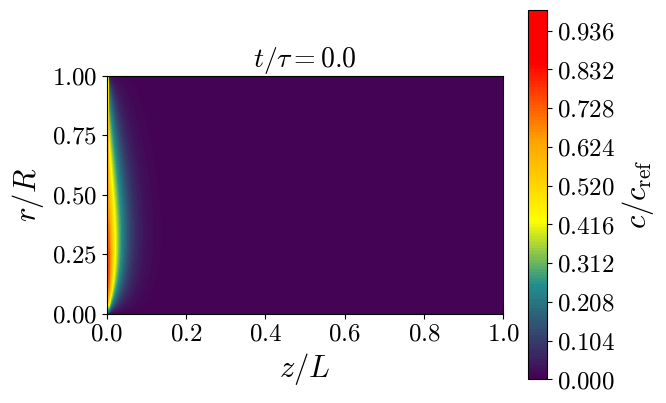

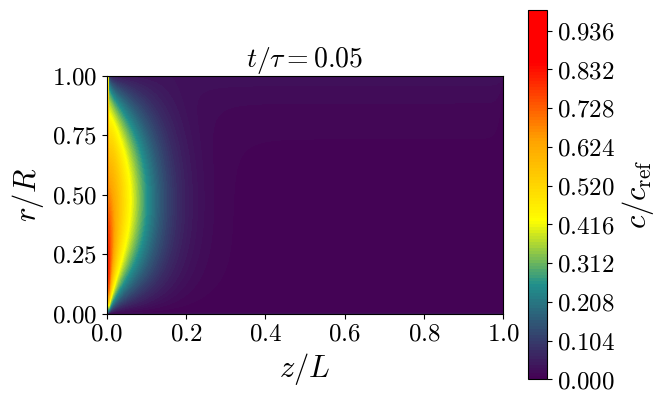

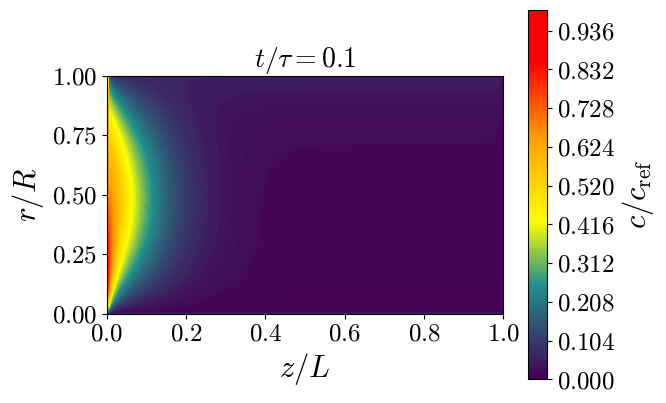

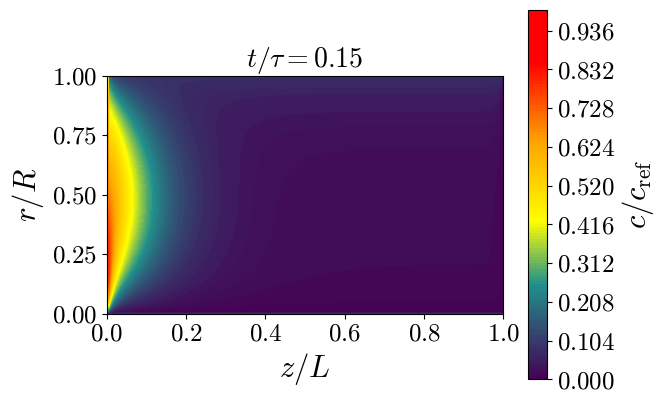

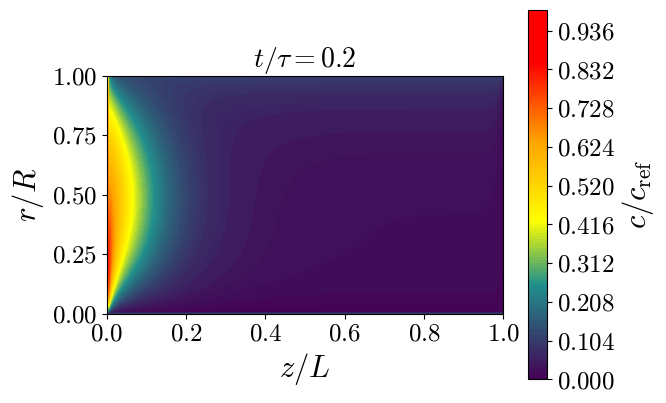

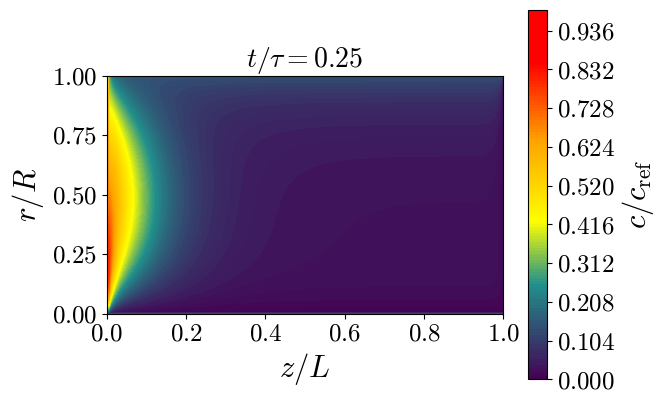

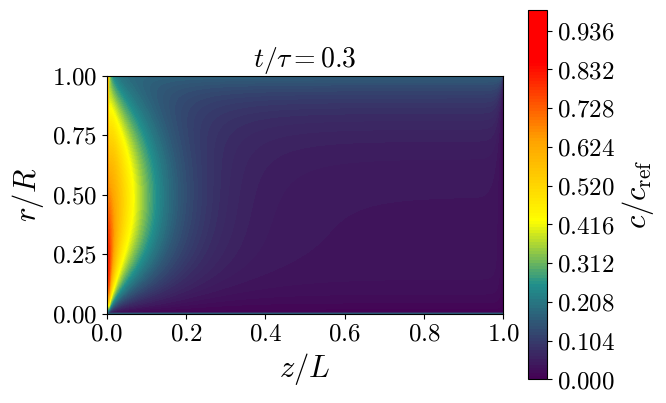

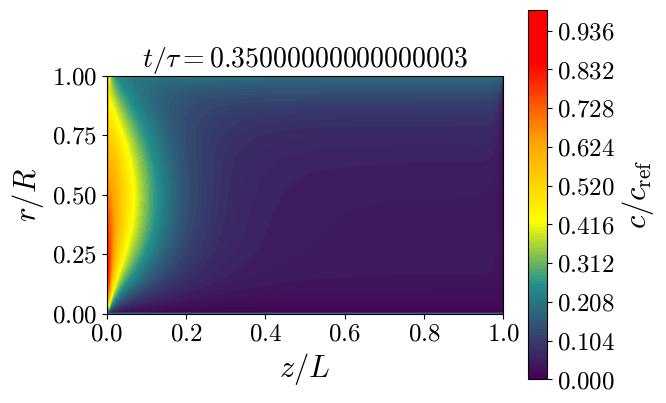

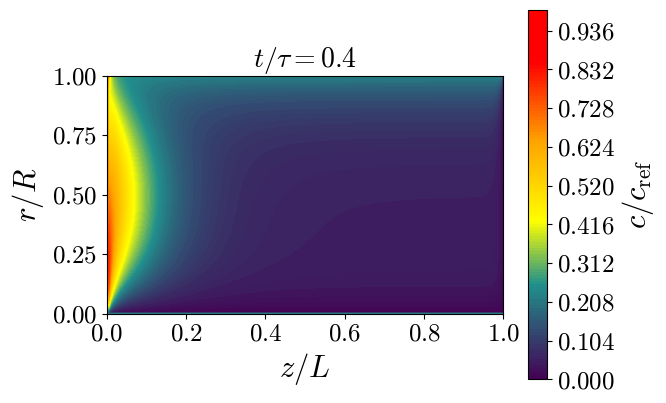

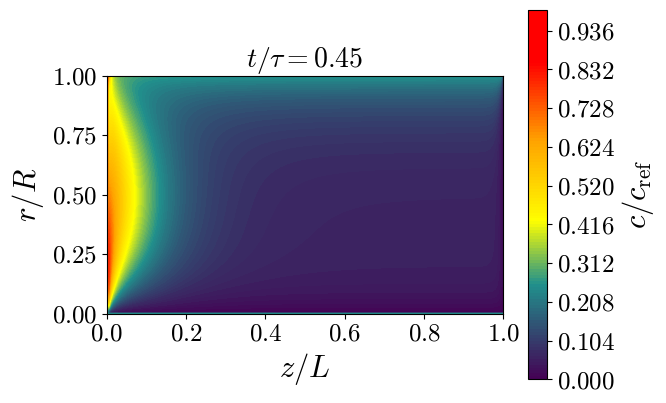

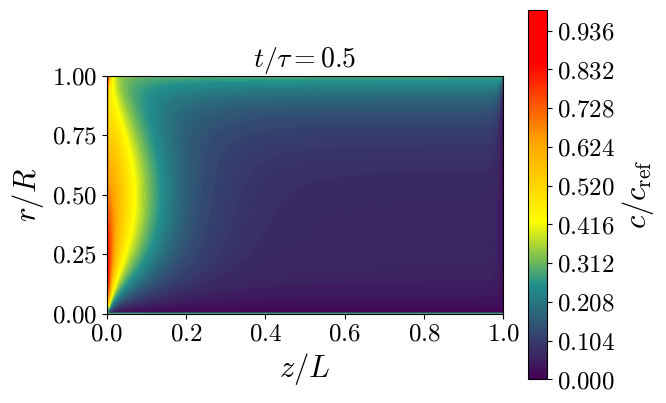

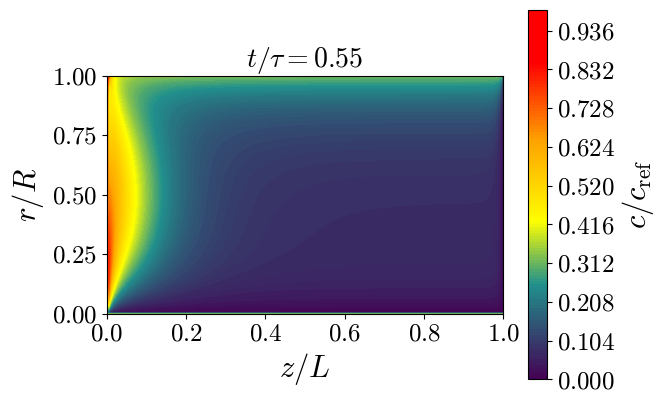

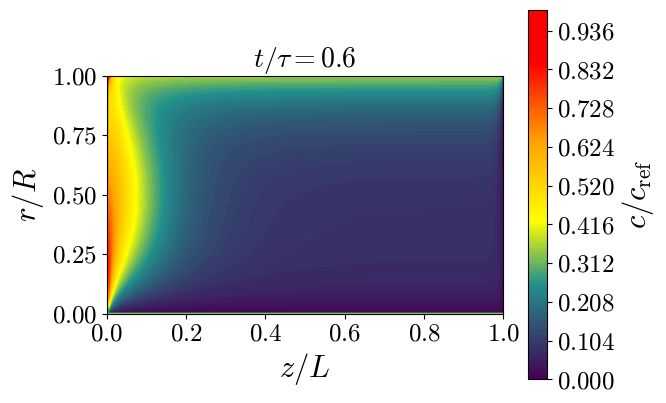

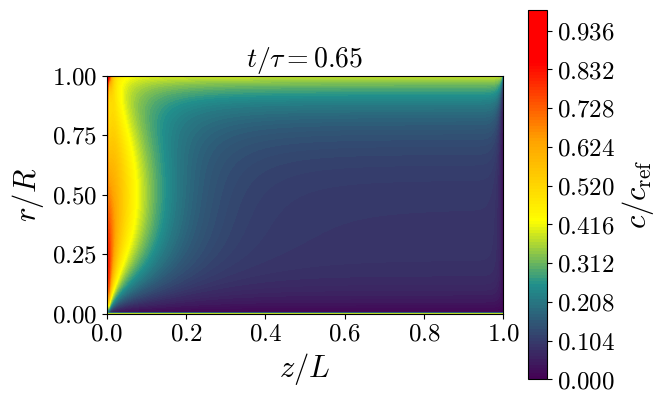

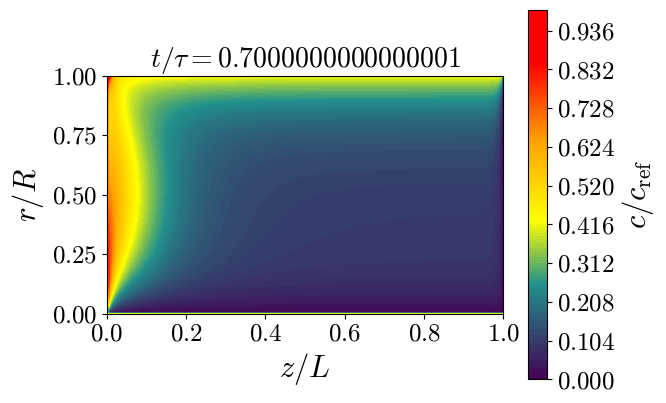

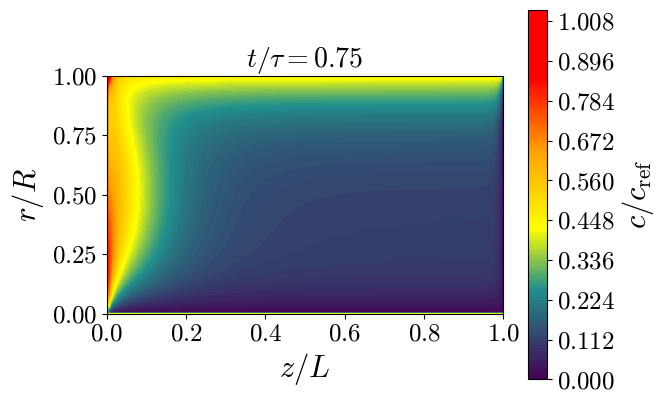

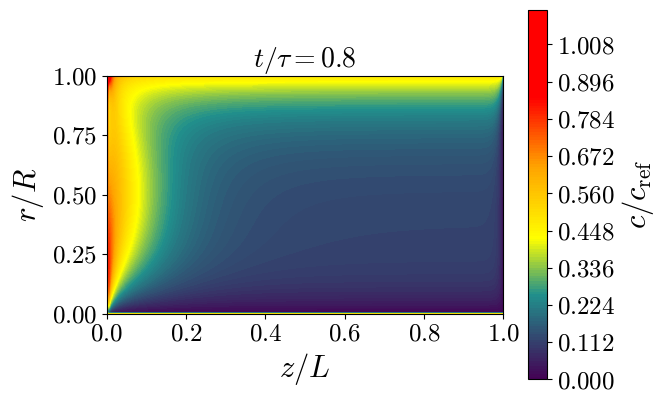

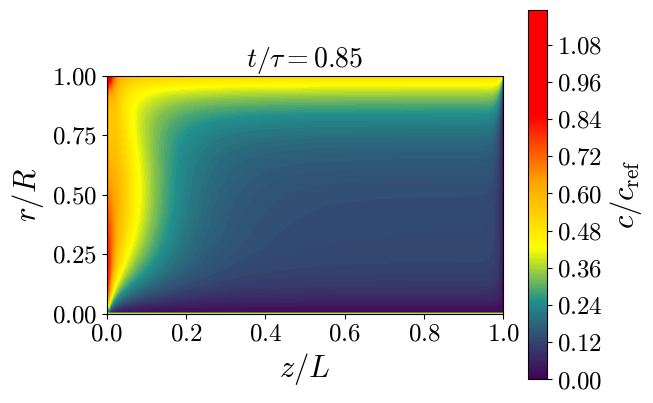

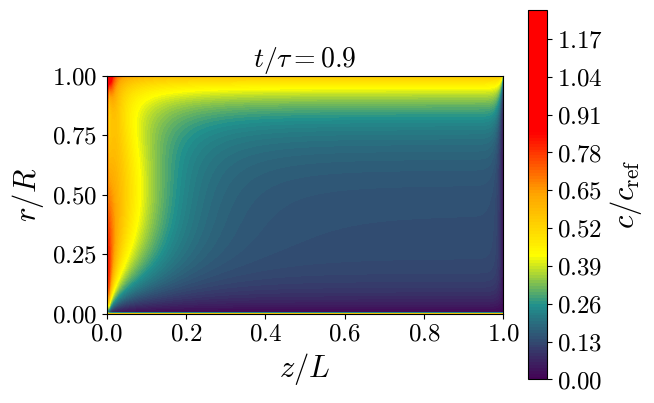

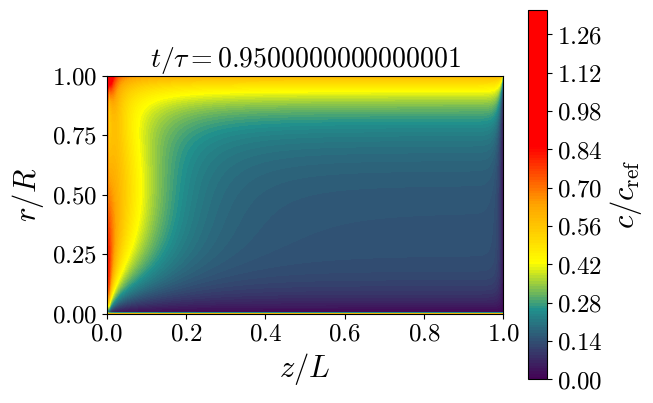

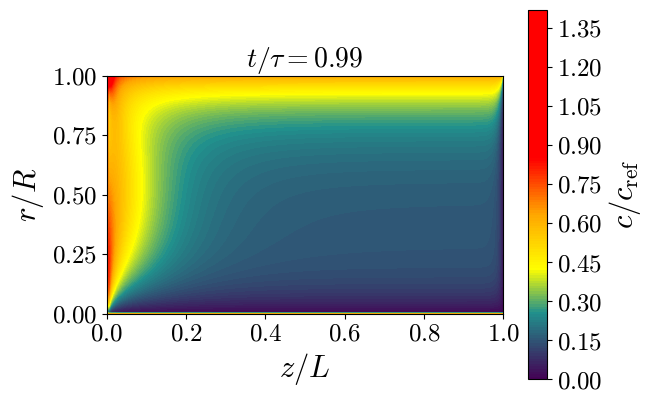

In [132]:
# Example
BC = (i, e, d)
A_matr = coeff_matrix(M)
C0 = f(ZZ, RR) # Initial concentration matrix

Ck = C0
for k in range(K):
    g = boundary_vector(grid, k, BC, M)
    C = concentration_scheme(grid, k, A_matr, Ck, g, BC, M)
    
    if k % 5 == 0 or k == K-1: 
        plt.figure()
        plt.title(f'$t/\\tau = {k*ht}$')
        contour_plot(ZZ, RR, C)
        plt.show()

    Ck = C